In [5]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=3c59f35669ca64edc6c0b8530fd70e1d6fbab46f4924476592dedb2558b46102
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier

In [6]:
# If ISLP is not installed yet, run this once:
# !pip install ISLP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ISLP import load_data

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [7]:
# Load Weekly dataset from ISLP
Weekly = load_data("Weekly")

# Basic look
print(Weekly.head())
print(Weekly.info())
print(Weekly.describe(include="all"))
print(Weekly["Direction"].value_counts())

   Year   Lag1   Lag2   Lag3   Lag4   Lag5    Volume  Today Direction
0  1990  0.816  1.572 -3.936 -0.229 -3.484  0.154976 -0.270      Down
1  1990 -0.270  0.816  1.572 -3.936 -0.229  0.148574 -2.576      Down
2  1990 -2.576 -0.270  0.816  1.572 -3.936  0.159837  3.514        Up
3  1990  3.514 -2.576 -0.270  0.816  1.572  0.161630  0.712        Up
4  1990  0.712  3.514 -2.576 -0.270  0.816  0.153728  1.178        Up
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), fl

            Year      Lag1      Lag2      Lag3      Lag4      Lag5    Volume  \
Year    1.000000 -0.032289 -0.033390 -0.030006 -0.031128 -0.030519  0.841942   
Lag1   -0.032289  1.000000 -0.074853  0.058636 -0.071274 -0.008183 -0.064951   
Lag2   -0.033390 -0.074853  1.000000 -0.075721  0.058382 -0.072499 -0.085513   
Lag3   -0.030006  0.058636 -0.075721  1.000000 -0.075396  0.060657 -0.069288   
Lag4   -0.031128 -0.071274  0.058382 -0.075396  1.000000 -0.075675 -0.061075   
Lag5   -0.030519 -0.008183 -0.072499  0.060657 -0.075675  1.000000 -0.058517   
Volume  0.841942 -0.064951 -0.085513 -0.069288 -0.061075 -0.058517  1.000000   
Today  -0.032460 -0.075032  0.059167 -0.071244 -0.007826  0.011013 -0.033078   

           Today  
Year   -0.032460  
Lag1   -0.075032  
Lag2    0.059167  
Lag3   -0.071244  
Lag4   -0.007826  
Lag5    0.011013  
Volume -0.033078  
Today   1.000000  


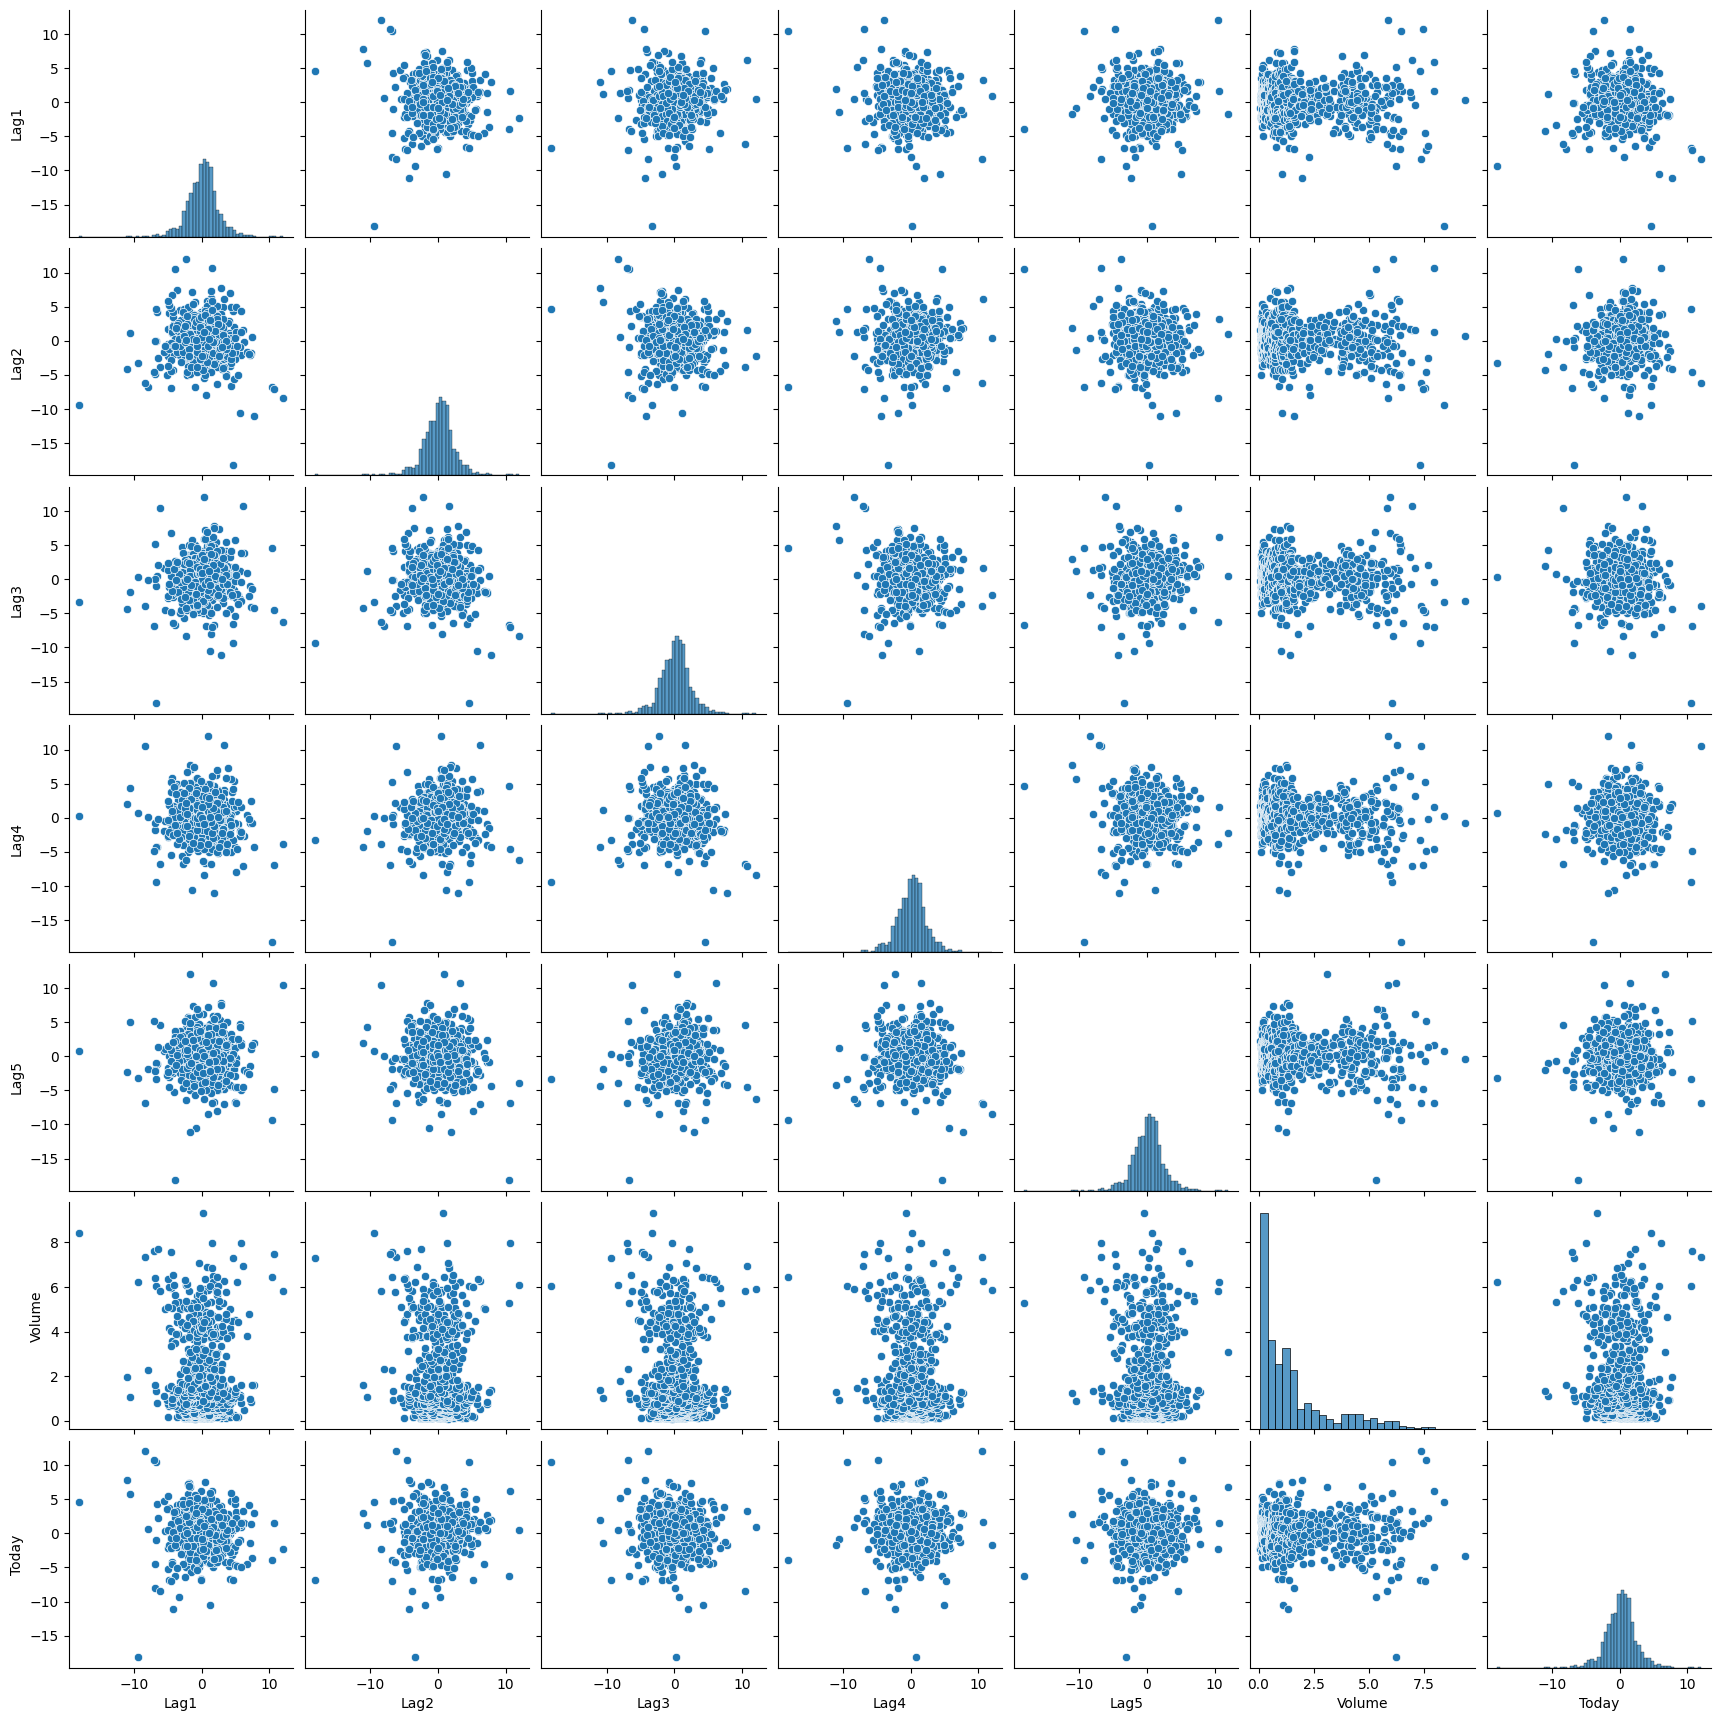

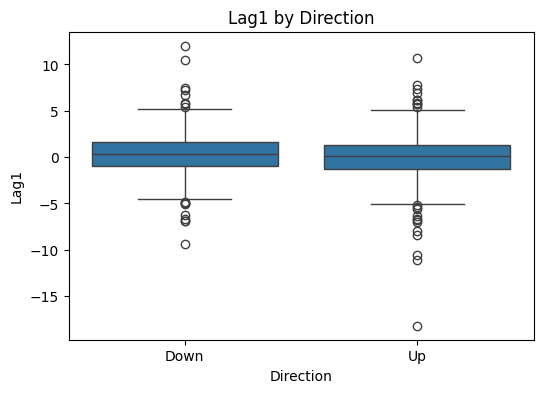

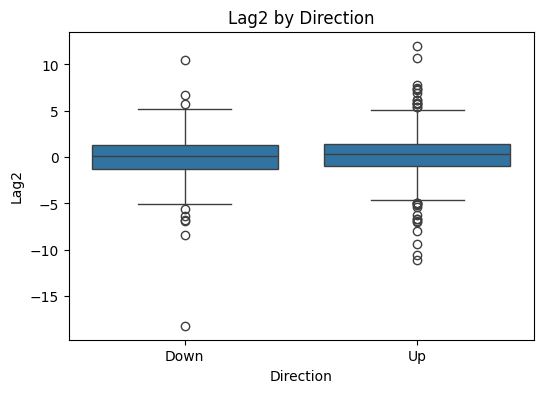

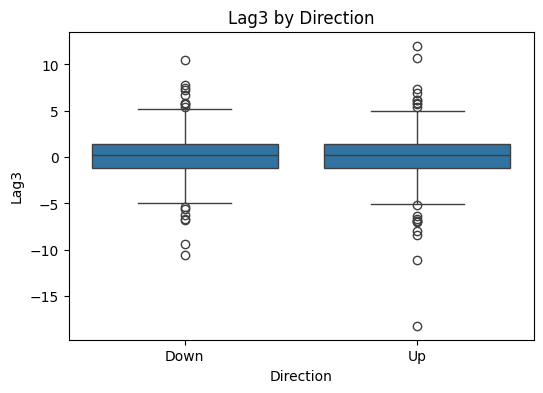

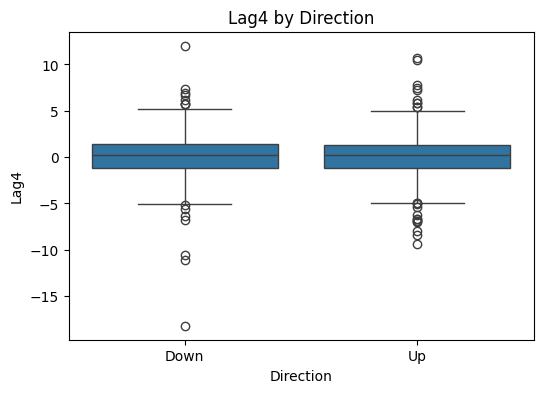

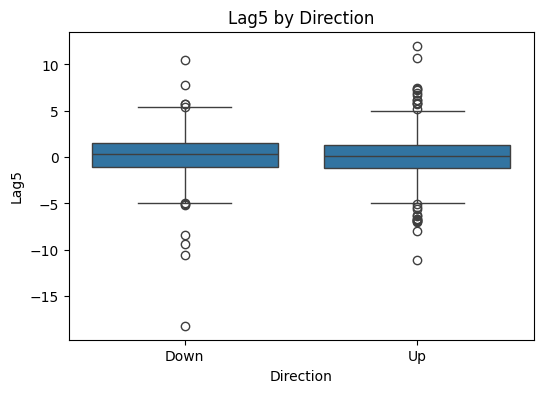

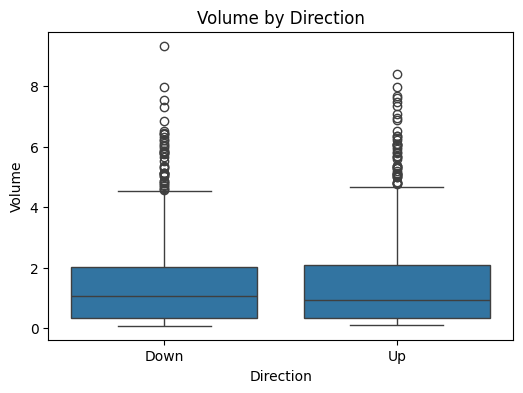

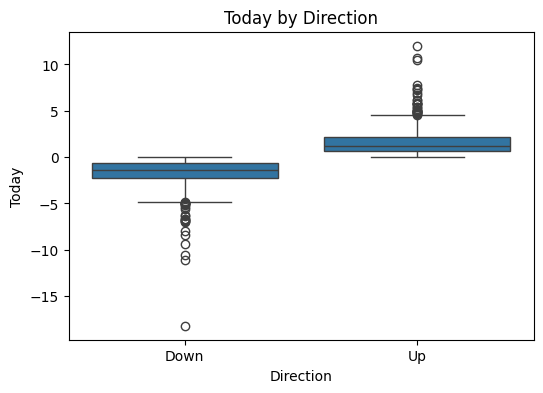

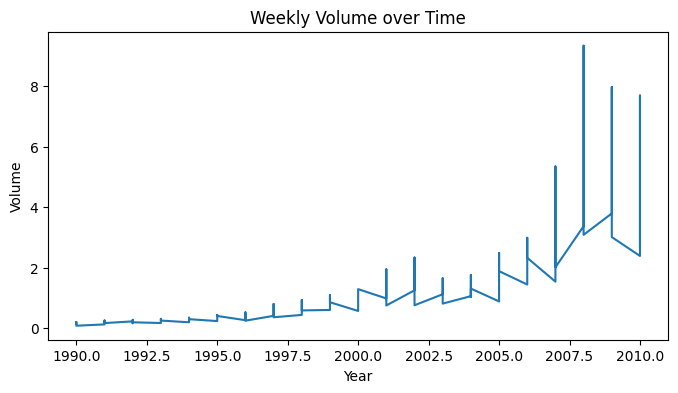

In [8]:
# Correlation among numeric variables
numeric_cols = Weekly.select_dtypes(include=[np.number]).columns
print(Weekly[numeric_cols].corr())

# Pairplot for selected columns
sns.pairplot(Weekly[["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume", "Today"]])
plt.show()

# Boxplots of numeric features by Direction
for col in ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume", "Today"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Direction", y=col, data=Weekly)
    plt.title(f"{col} by Direction")
    plt.show()

# Time trend for Volume
plt.figure(figsize=(8, 4))
plt.plot(Weekly["Year"], Weekly["Volume"])
plt.title("Weekly Volume over Time")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.show()

  Predictor  Coefficient
0      Lag1    -0.041234
1      Lag2     0.058392
2      Lag3    -0.016041
3      Lag4    -0.027779
4      Lag5    -0.014453
5    Volume    -0.022739
Intercept: 0.2668509535254939
Confusion Matrix:
[[ 54 430]
 [ 48 557]]
Accuracy: 0.5610651974288338


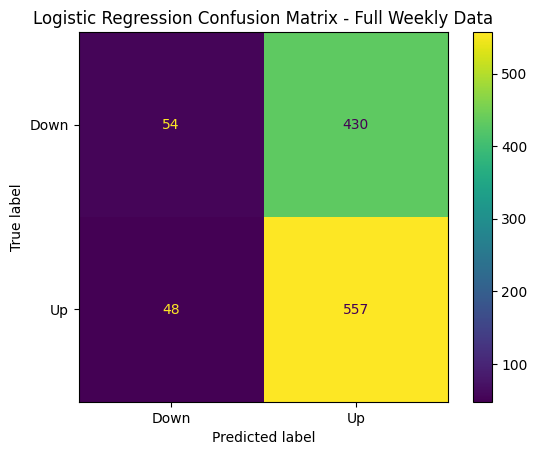

In [9]:
# Prepare X and y
X_full = Weekly[["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]]
y_full = Weekly["Direction"]

# Encode response so Up = 1, Down = 0
y_full_num = np.where(y_full == "Up", 1, 0)

# Logistic regression on full data
log_full = LogisticRegression(max_iter=5000)
log_full.fit(X_full, y_full_num)

# Coefficients
coef_df = pd.DataFrame({
    "Predictor": X_full.columns,
    "Coefficient": log_full.coef_[0]
})
print(coef_df)
print("Intercept:", log_full.intercept_[0])

# Predictions on full data
y_pred_full = log_full.predict(X_full)

# Confusion matrix and accuracy
cm_full = confusion_matrix(y_full_num, y_pred_full)
acc_full = accuracy_score(y_full_num, y_pred_full)

print("Confusion Matrix:")
print(cm_full)
print("Accuracy:", acc_full)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_full, display_labels=["Down", "Up"])
disp.plot()
plt.title("Logistic Regression Confusion Matrix - Full Weekly Data")
plt.show()

Logistic Regression with Lag2 only
Confusion Matrix:
[[ 9 34]
 [ 5 56]]
Accuracy: 0.625


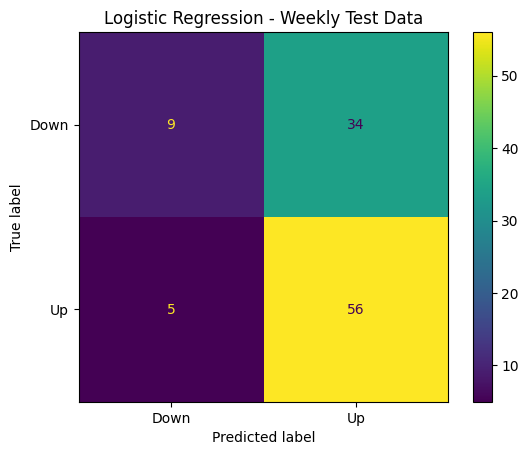

In [10]:
train = Weekly[Weekly["Year"] < 2009].copy()
test = Weekly[Weekly["Year"] >= 2009].copy()

X_train_lag2 = train[["Lag2"]]
X_test_lag2 = test[["Lag2"]]

y_train = train["Direction"]
y_test = test["Direction"]

y_train_num = np.where(y_train == "Up", 1, 0)
y_test_num = np.where(y_test == "Up", 1, 0)

# Logistic regression with Lag2 only
log_lag2 = LogisticRegression(max_iter=5000)
log_lag2.fit(X_train_lag2, y_train_num)

y_pred_log = log_lag2.predict(X_test_lag2)

cm_log = confusion_matrix(y_test_num, y_pred_log)
acc_log = accuracy_score(y_test_num, y_pred_log)

print("Logistic Regression with Lag2 only")
print("Confusion Matrix:")
print(cm_log)
print("Accuracy:", acc_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Down", "Up"])
disp.plot()
plt.title("Logistic Regression - Weekly Test Data")
plt.show()

LDA with Lag2 only
Confusion Matrix:
[[ 9 34]
 [ 5 56]]
Accuracy: 0.625


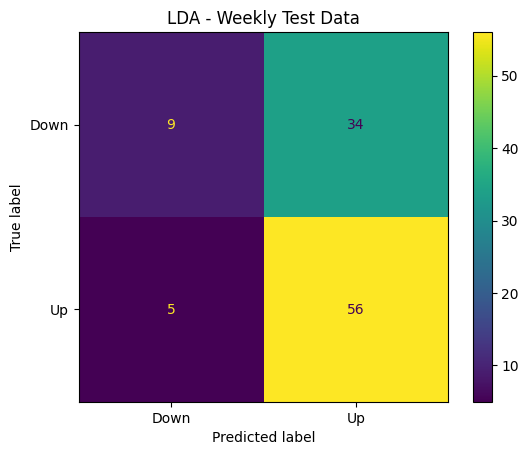

In [11]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_lag2, y_train)

y_pred_lda = lda.predict(X_test_lag2)

cm_lda = confusion_matrix(y_test, y_pred_lda, labels=["Down", "Up"])
acc_lda = accuracy_score(y_test, y_pred_lda)

print("LDA with Lag2 only")
print("Confusion Matrix:")
print(cm_lda)
print("Accuracy:", acc_lda)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=["Down", "Up"])
disp.plot()
plt.title("LDA - Weekly Test Data")
plt.show()

QDA with Lag2 only
Confusion Matrix:
[[ 0 43]
 [ 0 61]]
Accuracy: 0.5865384615384616


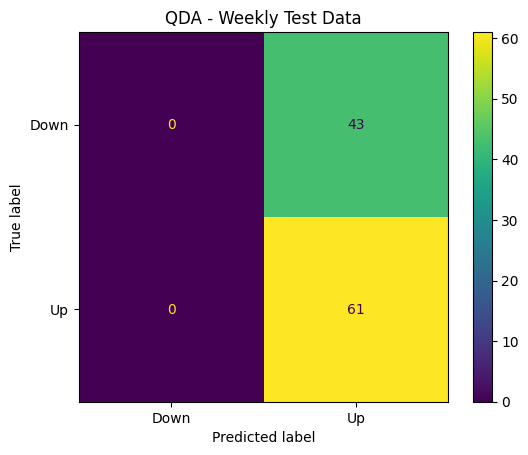

In [12]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_lag2, y_train)

y_pred_qda = qda.predict(X_test_lag2)

cm_qda = confusion_matrix(y_test, y_pred_qda, labels=["Down", "Up"])
acc_qda = accuracy_score(y_test, y_pred_qda)

print("QDA with Lag2 only")
print("Confusion Matrix:")
print(cm_qda)
print("Accuracy:", acc_qda)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_qda, display_labels=["Down", "Up"])
disp.plot()
plt.title("QDA - Weekly Test Data")
plt.show()

KNN with K=1 and Lag2 only
Confusion Matrix:
[[22 21]
 [32 29]]
Accuracy: 0.49038461538461536


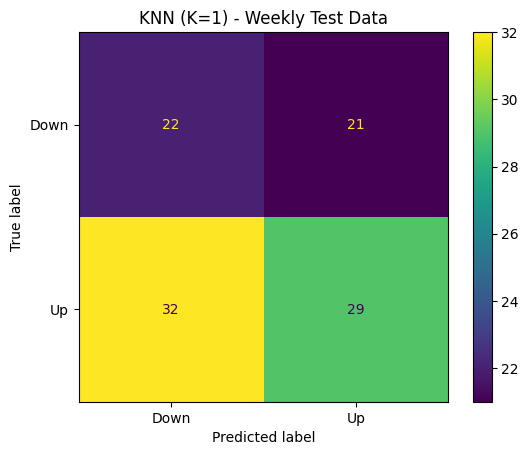

In [13]:
knn1 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=1))
])

knn1.fit(X_train_lag2, y_train)
y_pred_knn1 = knn1.predict(X_test_lag2)

cm_knn1 = confusion_matrix(y_test, y_pred_knn1, labels=["Down", "Up"])
acc_knn1 = accuracy_score(y_test, y_pred_knn1)

print("KNN with K=1 and Lag2 only")
print("Confusion Matrix:")
print(cm_knn1)
print("Accuracy:", acc_knn1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn1, display_labels=["Down", "Up"])
disp.plot()
plt.title("KNN (K=1) - Weekly Test Data")
plt.show()

Naive Bayes with Lag2 only
Confusion Matrix:
[[ 0 43]
 [ 0 61]]
Accuracy: 0.5865384615384616


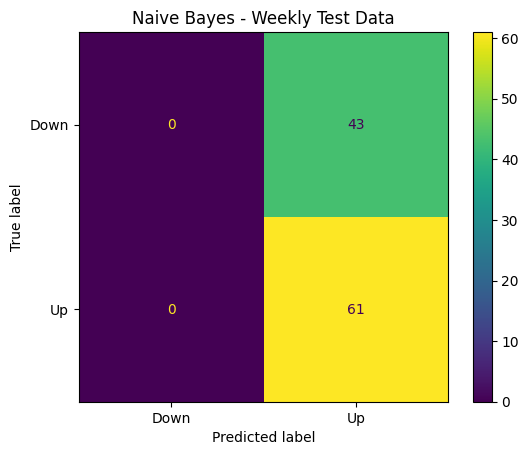

In [14]:
nb = GaussianNB()
nb.fit(X_train_lag2, y_train)

y_pred_nb = nb.predict(X_test_lag2)

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=["Down", "Up"])
acc_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes with Lag2 only")
print("Confusion Matrix:")
print(cm_nb)
print("Accuracy:", acc_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=["Down", "Up"])
disp.plot()
plt.title("Naive Bayes - Weekly Test Data")
plt.show()

In [15]:
results_weekly = pd.DataFrame({
    "Method": ["Logistic Regression", "LDA", "QDA", "KNN (K=1)", "Naive Bayes"],
    "Accuracy": [acc_log, acc_lda, acc_qda, acc_knn1, acc_nb]
}).sort_values(by="Accuracy", ascending=False)

print(results_weekly)

                Method  Accuracy
0  Logistic Regression  0.625000
1                  LDA  0.625000
2                  QDA  0.586538
4          Naive Bayes  0.586538
3            KNN (K=1)  0.490385


In [16]:
predictor_sets = {
    "Lag2": ["Lag2"],
    "Lag1_Lag2": ["Lag1", "Lag2"],
    "Lag1_to_Lag5": ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5"],
    "Lag1_to_Lag5_Volume": ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]
}

weekly_experiment_results = []

for name, cols in predictor_sets.items():
    X_train = train[cols]
    X_test = test[cols]

    # Logistic
    model_log = LogisticRegression(max_iter=5000)
    model_log.fit(X_train, y_train_num)
    pred_log = model_log.predict(X_test)
    weekly_experiment_results.append([
        "Logistic Regression", name, accuracy_score(y_test_num, pred_log),
        confusion_matrix(y_test_num, pred_log)
    ])

    # LDA
    model_lda = LinearDiscriminantAnalysis()
    model_lda.fit(X_train, y_train)
    pred_lda = model_lda.predict(X_test)
    weekly_experiment_results.append([
        "LDA", name, accuracy_score(y_test, pred_lda),
        confusion_matrix(y_test, pred_lda, labels=["Down", "Up"])
    ])

    # QDA
    model_qda = QuadraticDiscriminantAnalysis()
    model_qda.fit(X_train, y_train)
    pred_qda = model_qda.predict(X_test)
    weekly_experiment_results.append([
        "QDA", name, accuracy_score(y_test, pred_qda),
        confusion_matrix(y_test, pred_qda, labels=["Down", "Up"])
    ])

    # Naive Bayes
    model_nb = GaussianNB()
    model_nb.fit(X_train, y_train)
    pred_nb = model_nb.predict(X_test)
    weekly_experiment_results.append([
        "Naive Bayes", name, accuracy_score(y_test, pred_nb),
        confusion_matrix(y_test, pred_nb, labels=["Down", "Up"])
    ])

    # KNN with several K values
    for k in [1, 3, 5, 7, 9]:
        model_knn = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ])
        model_knn.fit(X_train, y_train)
        pred_knn = model_knn.predict(X_test)
        weekly_experiment_results.append([
            f"KNN (K={k})", name, accuracy_score(y_test, pred_knn),
            confusion_matrix(y_test, pred_knn, labels=["Down", "Up"])
        ])

weekly_exp_df = pd.DataFrame(
    weekly_experiment_results,
    columns=["Method", "Predictors", "Accuracy", "Confusion_Matrix"]
).sort_values(by="Accuracy", ascending=False)

print(weekly_exp_df.head(15))

                 Method           Predictors  Accuracy      Confusion_Matrix
0   Logistic Regression                 Lag2  0.625000    [[9, 34], [5, 56]]
1                   LDA                 Lag2  0.625000    [[9, 34], [5, 56]]
2                   QDA                 Lag2  0.586538    [[0, 43], [0, 61]]
3           Naive Bayes                 Lag2  0.586538    [[0, 43], [0, 61]]
10                  LDA            Lag1_Lag2  0.576923    [[7, 36], [8, 53]]
9   Logistic Regression            Lag1_Lag2  0.576923    [[7, 36], [8, 53]]
5             KNN (K=3)                 Lag2  0.567308  [[16, 27], [18, 43]]
8             KNN (K=9)                 Lag2  0.557692  [[17, 26], [20, 41]]
11                  QDA            Lag1_Lag2  0.557692   [[7, 36], [10, 51]]
35            KNN (K=9)  Lag1_to_Lag5_Volume  0.557692  [[23, 20], [26, 35]]
25            KNN (K=7)         Lag1_to_Lag5  0.557692  [[19, 24], [22, 39]]
23            KNN (K=3)         Lag1_to_Lag5  0.557692  [[21, 22], [24, 37]]

In [1]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv


In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving sample_submission.csv to sample_submission.csv


In [17]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (20758, 18)
Test shape: (13840, 17)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [18]:
print(train.columns)

Index(['id', 'Gender', 'Age', 'Height', 'Weight',
       'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [20]:
# Inspect columns and confirm target
print(train.columns)
print(train.head())
print(sample_submission.head())

Index(['id', 'Gender', 'Age', 'Height', 'Weight',
       'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')
   id  Gender        Age    Height      Weight family_history_with_overweight  \
0   0    Male  24.443011  1.699998   81.669950                            yes   
1   1  Female  18.000000  1.560000   57.000000                            yes   
2   2  Female  18.000000  1.711460   50.165754                            yes   
3   3  Female  20.952737  1.710730  131.274851                            yes   
4   4    Male  31.641081  1.914186   93.798055                            yes   

  FAVC      FCVC       NCP        CAEC SMOKE      CH2O SCC       FAF  \
0  yes  2.000000  2.983297   Sometimes    no  2.763573  no  0.000000   
1  yes  2.000000  3.000000  Frequently    no  2.000000  no  1.000000   
2  yes  1.880534  1.411685   Sometimes    no  1.910378  no  0.866045   
3  

In [21]:
# Set target column
target = "NObeyesdad"

# Separate features and target
X = train.drop(columns=[target])
y = train[target]

# Keep test features
X_test_kaggle = test.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test shape:", X_test_kaggle.shape)

X shape: (20758, 17)
y shape: (20758,)
Test shape: (13840, 17)


In [22]:
# Handle ID column if present
id_col = None
for col in ["id", "Id", "ID"]:
    if col in X.columns:
        id_col = col
        break

if id_col is not None:
    X = X.drop(columns=[id_col])
    X_test_ids = X_test_kaggle[id_col]
    X_test_kaggle = X_test_kaggle.drop(columns=[id_col])
else:
    X_test_ids = pd.Series(np.arange(len(X_test_kaggle)), name="id")

print("ID column:", id_col)
print("Feature columns after ID handling:", X.columns.tolist())

ID column: id
Feature columns after ID handling: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']


In [23]:
# One-hot encode categorical predictors
X = pd.get_dummies(X, drop_first=True)
X_test_kaggle = pd.get_dummies(X_test_kaggle, drop_first=True)

# Align train/test columns
X, X_test_kaggle = X.align(X_test_kaggle, join="left", axis=1, fill_value=0)

print("Processed X shape:", X.shape)
print("Processed test shape:", X_test_kaggle.shape)

Processed X shape: (20758, 22)
Processed test shape: (13840, 22)


In [24]:
# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [25]:
# Holdout split for internal validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(X_train.shape, X_val.shape)

(16606, 22) (4152, 22)


In [26]:
# Multinomial Logistic Regression
log_model = LogisticRegression(
    max_iter=5000,
    multi_class="multinomial",
    solver="lbfgs"
)

log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_val)

log_acc = accuracy_score(y_val, log_preds)
print("Multinomial Logistic Regression Accuracy:", log_acc)
print(confusion_matrix(y_val, log_preds))
print(classification_report(y_val, log_preds, target_names=le.classes_))

Multinomial Logistic Regression Accuracy: 0.8574181117533719
[[487  17   0   0   0   1   0]
 [ 62 492   1   0   0  48  14]
 [  1   0 489  35   9   8  40]
 [  0   0  24 625   0   0   1]
 [  0   0   0   1 808   0   0]
 [  2  59  18   0   0 325  81]
 [  0  13  89   8   0  60 334]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.88      0.96      0.92       505
      Normal_Weight       0.85      0.80      0.82       617
     Obesity_Type_I       0.79      0.84      0.81       582
    Obesity_Type_II       0.93      0.96      0.95       650
   Obesity_Type_III       0.99      1.00      0.99       809
 Overweight_Level_I       0.74      0.67      0.70       485
Overweight_Level_II       0.71      0.66      0.69       504

           accuracy                           0.86      4152
          macro avg       0.84      0.84      0.84      4152
       weighted avg       0.85      0.86      0.86      4152



In [27]:
# LDA
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)
lda_preds = lda_model.predict(X_val)

lda_acc = accuracy_score(y_val, lda_preds)
print("LDA Accuracy:", lda_acc)
print(confusion_matrix(y_val, lda_preds))
print(classification_report(y_val, lda_preds, target_names=le.classes_))

LDA Accuracy: 0.8229768786127167
[[470  33   0   0   0   1   1]
 [101 442   1   0   0  54  19]
 [  1   1 456  54   7  13  50]
 [  0   0  29 612   5   0   4]
 [  0   0   1   2 805   1   0]
 [  6  74  16   0   0 289 100]
 [  0   9  82   4   0  66 343]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.81      0.93      0.87       505
      Normal_Weight       0.79      0.72      0.75       617
     Obesity_Type_I       0.78      0.78      0.78       582
    Obesity_Type_II       0.91      0.94      0.93       650
   Obesity_Type_III       0.99      1.00      0.99       809
 Overweight_Level_I       0.68      0.60      0.64       485
Overweight_Level_II       0.66      0.68      0.67       504

           accuracy                           0.82      4152
          macro avg       0.80      0.81      0.80      4152
       weighted avg       0.82      0.82      0.82      4152



In [28]:
# QDA
qda_model = QuadraticDiscriminantAnalysis()
qda_model.fit(X_train, y_train)
qda_preds = qda_model.predict(X_val)

qda_acc = accuracy_score(y_val, qda_preds)
print("QDA Accuracy:", qda_acc)
print(confusion_matrix(y_val, qda_preds))
print(classification_report(y_val, qda_preds, target_names=le.classes_))

QDA Accuracy: 0.19484585741811175
[[  0   0   0   0 505   0   0]
 [  0   0   0   0 617   0   0]
 [  0   0   0   0 582   0   0]
 [  0   0   0   0 650   0   0]
 [  0   0   0   0 809   0   0]
 [  0   0   0   0 485   0   0]
 [  0   0   0   0 504   0   0]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.00      0.00      0.00       505
      Normal_Weight       0.00      0.00      0.00       617
     Obesity_Type_I       0.00      0.00      0.00       582
    Obesity_Type_II       0.00      0.00      0.00       650
   Obesity_Type_III       0.19      1.00      0.33       809
 Overweight_Level_I       0.00      0.00      0.00       485
Overweight_Level_II       0.00      0.00      0.00       504

           accuracy                           0.19      4152
          macro avg       0.03      0.14      0.05      4152
       weighted avg       0.04      0.19      0.06      4152



In [29]:
# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_val)

nb_acc = accuracy_score(y_val, nb_preds)
print("Naive Bayes Accuracy:", nb_acc)
print(confusion_matrix(y_val, nb_preds))
print(classification_report(y_val, nb_preds, target_names=le.classes_))

Naive Bayes Accuracy: 0.6095857418111753
[[412  22  64   0   2   5   0]
 [230 165 116  11  17  47  31]
 [  1   7 275 249   5  14  31]
 [  0   0  12 625   0   3  10]
 [  0   1   0   1 806   1   0]
 [ 22  54 164  60   9 135  41]
 [  1  37 159 172   1  21 113]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.62      0.82      0.70       505
      Normal_Weight       0.58      0.27      0.37       617
     Obesity_Type_I       0.35      0.47      0.40       582
    Obesity_Type_II       0.56      0.96      0.71       650
   Obesity_Type_III       0.96      1.00      0.98       809
 Overweight_Level_I       0.60      0.28      0.38       485
Overweight_Level_II       0.50      0.22      0.31       504

           accuracy                           0.61      4152
          macro avg       0.59      0.57      0.55      4152
       weighted avg       0.61      0.61      0.58      4152



In [30]:
# SVM
svm_model = SVC(kernel="rbf")
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_val)

svm_acc = accuracy_score(y_val, svm_preds)
print("SVM Accuracy:", svm_acc)
print(confusion_matrix(y_val, svm_preds))
print(classification_report(y_val, svm_preds, target_names=le.classes_))

SVM Accuracy: 0.7165221579961464
[[431  73   0   0   0   1   0]
 [122 377   0   0   0 103  15]
 [  1   1 285  26  32   5 232]
 [  0   0  47 489 112   0   2]
 [  0   0   3   1 803   0   2]
 [  5  94   6   0   0 226 154]
 [  0  24  73  13   0  30 364]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.77      0.85      0.81       505
      Normal_Weight       0.66      0.61      0.64       617
     Obesity_Type_I       0.69      0.49      0.57       582
    Obesity_Type_II       0.92      0.75      0.83       650
   Obesity_Type_III       0.85      0.99      0.91       809
 Overweight_Level_I       0.62      0.47      0.53       485
Overweight_Level_II       0.47      0.72      0.57       504

           accuracy                           0.72      4152
          macro avg       0.71      0.70      0.70      4152
       weighted avg       0.73      0.72      0.71      4152



In [31]:
# Compare required models
results_kaggle = pd.DataFrame({
    "Model": [
        "Multinomial Logistic Regression",
        "LDA",
        "QDA",
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        log_acc,
        lda_acc,
        qda_acc,
        nb_acc,
        svm_acc
    ]
}).sort_values(by="Accuracy", ascending=False)

results_kaggle

,Model,Accuracy
0,Multinomial Logistic Regression,0.857418
1,LDA,0.822977
4,SVM,0.716522
3,Naive Bayes,0.609586
2,QDA,0.194846


In [32]:
# Logistic submission
log_test_preds = log_model.predict(X_test_kaggle)
log_test_labels = le.inverse_transform(log_test_preds)

submission_log = sample_submission.copy()
submission_log[target] = log_test_labels
submission_log.to_csv("submission_logistic.csv", index=False)

submission_log.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


In [33]:
# LDA submission
lda_test_preds = lda_model.predict(X_test_kaggle)
lda_test_labels = le.inverse_transform(lda_test_preds)

submission_lda = sample_submission.copy()
submission_lda[target] = lda_test_labels
submission_lda.to_csv("submission_lda.csv", index=False)

submission_lda.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_II
4,20762,Obesity_Type_III


In [34]:
# QDA submission
qda_test_preds = qda_model.predict(X_test_kaggle)
qda_test_labels = le.inverse_transform(qda_test_preds)

submission_qda = sample_submission.copy()
submission_qda[target] = qda_test_labels
submission_qda.to_csv("submission_qda.csv", index=False)

submission_qda.head()

,id,NObeyesdad
0,20758,Obesity_Type_III
1,20759,Obesity_Type_III
2,20760,Obesity_Type_III
3,20761,Obesity_Type_III
4,20762,Obesity_Type_III


In [35]:
# Naive Bayes submission
nb_test_preds = nb_model.predict(X_test_kaggle)
nb_test_labels = le.inverse_transform(nb_test_preds)

submission_nb = sample_submission.copy()
submission_nb[target] = nb_test_labels
submission_nb.to_csv("submission_nb.csv", index=False)

submission_nb.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Obesity_Type_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_II
4,20762,Obesity_Type_III


In [36]:
# SVM submission
svm_test_preds = svm_model.predict(X_test_kaggle)
svm_test_labels = le.inverse_transform(svm_test_preds)

submission_svm = sample_submission.copy()
submission_svm[target] = svm_test_labels
submission_svm.to_csv("submission_svm.csv", index=False)

submission_svm.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Normal_Weight
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


In [37]:
from google.colab import files

files.download("submission_logistic.csv")
files.download("submission_lda.csv")
files.download("submission_qda.csv")
files.download("submission_nb.csv")
files.download("submission_svm.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
print(train.columns)

train.info()

train.describe()

train.head()

Index(['id', 'Gender', 'Age', 'Height', 'Weight',
       'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float6

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [39]:
# Target variable
target = "NObeyesdad"

# Separate features and target
X = train.drop(columns=[target])
y = train[target]

# Keep test features
X_test = test.copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20758, 17)
Target shape: (20758,)


In [40]:
# Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns so train/test match
X, X_test = X.align(X_test, join="left", axis=1, fill_value=0)

print("Processed feature shape:", X.shape)

Processed feature shape: (20758, 23)


In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print(X_train.shape, X_val.shape)

(16606, 23) (4152, 23)


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=5000, multi_class="multinomial")

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_val)

log_acc = accuracy_score(y_val, log_preds)

print("Multinomial Logistic Regression Accuracy:", log_acc)

Multinomial Logistic Regression Accuracy: 0.691233140655106


In [44]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train, y_train)

lda_preds = lda_model.predict(X_val)

lda_acc = accuracy_score(y_val, lda_preds)

print("LDA Accuracy:", lda_acc)

LDA Accuracy: 0.8227360308285164


In [45]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_val)

nb_acc = accuracy_score(y_val, nb_preds)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.6811175337186898


In [46]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf")

svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_val)

svm_acc = accuracy_score(y_val, svm_preds)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.1936416184971098


In [47]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Logistic Regression",
        "LDA",
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        log_acc,
        lda_acc,
        nb_acc,
        svm_acc
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,LDA,0.822736
0,Multinomial Logistic Regression,0.691233
2,Naive Bayes,0.681118
3,SVM,0.193642


In [48]:
# Predict test data
test_preds = log_model.predict(X_test)

# Convert labels back to original class names
test_preds_labels = le.inverse_transform(test_preds)

submission = sample_submission.copy()

submission[target] = test_preds_labels

submission.to_csv("submission_logistic.csv", index=False)

submission.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_III
4,20762,Obesity_Type_III


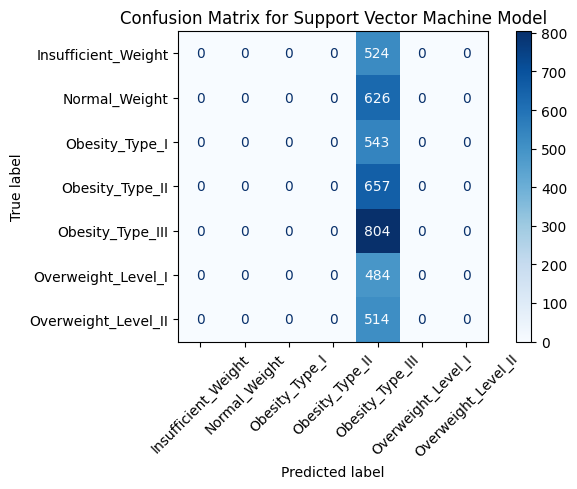

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Generate predictions again (safe even if you already did it)
svm_preds = svm_model.predict(X_val)

# Create confusion matrix
cm = confusion_matrix(y_val, svm_preds)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7,5))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix for Support Vector Machine Model")
plt.tight_layout()

# Save image for your paper
plt.savefig("svm_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [50]:
# Load datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Preview
train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [51]:
# Separate features and target
X = train.drop('NObeyesdad', axis=1)
y = train['NObeyesdad']

In [52]:
# Combine train and test for consistent encoding
combined = pd.concat([X, test], axis=0)

# One-hot encoding
combined = pd.get_dummies(combined)

# Split back
X = combined[:len(X)]
test = combined[len(X):]

In [55]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
dt_preds = dt_model.predict(X_val)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_val, dt_preds))
print(confusion_matrix(y_val, dt_preds))

Decision Tree Accuracy: 0.8410404624277457
[[459  60   1   0   0   3   1]
 [ 55 488   0   0   0  75   8]
 [  2   2 431  17   3  22  66]
 [  0   0  31 615   3   0   8]
 [  0   0   1   1 802   0   0]
 [  2  52  18   0   1 327  84]
 [  0  11  48   8   0  77 370]]


In [56]:
# Bagged model
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bag_model.fit(X_train, y_train)

# Predictions
bag_preds = bag_model.predict(X_val)

# Evaluation
print("Bagging Accuracy:", accuracy_score(y_val, bag_preds))
print(confusion_matrix(y_val, bag_preds))

Bagging Accuracy: 0.8945086705202312
[[493  27   0   0   0   1   3]
 [ 28 541   1   0   0  54   2]
 [  2   0 467  11   1  16  46]
 [  1   0  19 636   1   0   0]
 [  0   0   1   1 802   0   0]
 [  1  41  10   0   0 366  66]
 [  0   9  37   6   0  53 409]]


In [57]:
# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_val)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_val, rf_preds))
print(confusion_matrix(y_val, rf_preds))

Random Forest Accuracy: 0.8892100192678227
[[474  47   0   0   0   2   1]
 [ 26 554   0   0   0  35  11]
 [  1   3 468  11   1  19  40]
 [  0   0  12 640   0   0   5]
 [  0   0   0   1 802   1   0]
 [  1  69   8   0   0 345  61]
 [  0  16  37   3   0  49 409]]


In [58]:
# Boosted model (Gradient Boosting)
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Predictions
gb_preds = gb_model.predict(X_val)

# Evaluation
print("Gradient Boosting Accuracy:", accuracy_score(y_val, gb_preds))
print(confusion_matrix(y_val, gb_preds))

Gradient Boosting Accuracy: 0.9024566473988439
[[492  29   0   0   0   2   1]
 [ 21 559   1   0   0  41   4]
 [  2   1 470  12   1  16  41]
 [  0   0  15 639   1   0   2]
 [  0   0   1   1 802   0   0]
 [  1  38  11   0   0 377  57]
 [  0   9  39   5   0  53 408]]


In [63]:
# Reload original test file to get correct id column
test_raw = pd.read_csv('test.csv')

In [64]:
# Train final model on FULL training data
gb_model.fit(X, y)

# Predict on test set
test_preds = gb_model.predict(test)

# Create submission file
submission = pd.DataFrame({
    "id": test_raw["id"],   # lowercase id
    "NObeyesdad": test_preds
})

submission.to_csv("submission.csv", index=False)

In [65]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>